In [1]:
# This code converts a visit file into Exposure objects one block at a time.

# VisitFileParser
#     ↓ (iterator)
# ExposureIterator  → yields raw text blocks
#     ↓
# ExposureParser    → converts block → Exposure object
#     ↓
# Exposure (data + behavior)
#     ↓
# Plotting layer


In [36]:
import argparse

from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch
from astropy.io import fits
import astropy.units as u
from astropy.wcs import WCS

import matplotlib.pyplot as plt 

import numpy as np

from pathlib import Path

import pysiaf

from dataclasses import dataclass, field
from typing import Optional

import re, os

# Functions and Classes

In [3]:
def roman_attitude(q):
    '''
    Calculate the RA, Dec, and V3PA based on input quaternion from visit file.
    Quaternion rotates ECI → BCS (scalar-last convention).

    Parameters
    ----------
    q : list
        Quaternion

    Returns
    ---------
    ra, dec, pa_v3
    '''

    x,y,z,w = q  # scalar-last

    # rotation matrix (ECI→BCS)
    R = np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w), 2*(x*z+y*w)],
        [2*(x*y+z*w), 1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x*x+y*y)]
    ])

    V1 = R[:,0]      # pointing
    V3 = R[:,2]      # +V3 (Roman definition)

    # --- RA/DEC ---
    V1 /= np.linalg.norm(V1)

    dec = np.arcsin(V1[2])
    ra  = np.arctan2(V1[1], V1[0])
    if ra < 0:
        ra += 2*np.pi

    # --- PA(+V3) ---
    Z = np.array([0.,0.,1.])

    N = Z - np.dot(Z,V1)*V1
    N /= np.linalg.norm(N)

    E = np.cross(N, V1)

    V3 -= np.dot(V3,V1)*V1
    V3 /= np.linalg.norm(V3)

    pa_v3 = np.degrees(np.arctan2(
        np.dot(V3,E),
        np.dot(V3,N)
    )) % 360

    return np.degrees(ra), np.degrees(dec), pa_v3

In [4]:
def retrieve_2mass_image(ra, dec, visitname, verbose=True, redownload=False, filter='J', fov=1.8):
    """Obtain from Aladin a 2MASS image for the pointing location of a JWST visit

    Uses HIPS2FITS service; see http://alasky.u-strasbg.fr/hips-image-services/hips2fits

    FITS files for the retrieved images are cached for re-use, in a subdirectory
    `image_cache` next to where this code is.

    Parameters
    ----------
    visit : VisitFileContents object
        Representation of some JWST visit file
    filter : string
        Which bandpass filter in 2MASS to get?
    verbose : bool
        more output text
    redownload : bool
        Even if image is already downloaded and cached, ignore that and download from Vizier again.

    """

    hips_catalog = f'CDS/P/2MASS/{filter}'  # also try 2MASS/color
    width = 1024
    height = 1024

    if fov!= 0.35:
        # if a non-default FOV is used, save that specially
        img_fn = os.path.join(f'img_2mass_{filter}_{visitname.strip(".vst")}_fov{fov}.fits')
    else:
        img_fn = os.path.join(f'img_2mass_{filter}_{visitname.strip(".vst")}.fits')

    if not os.path.exists(img_fn) or redownload:

        # optional / TBD - add PA into this query?
        # rotation_angle=90.0
        url = f'http://alasky.u-strasbg.fr/hips-image-services/hips2fits?hips={(hips_catalog)}&width={width}&height={height}&fov={fov}&projection=TAN&coordsys=icrs&ra={ra}&dec={dec}'

        if verbose:
            print(f"Retrieving 2MASS image from Aladin near ra={ra} & dec={dec}...")

        with fits.open(url) as hdu:
            hdu.writeto(img_fn, overwrite=True)
            if verbose:
                print(f"   Saved to {img_fn}")
    hdu = fits.open(img_fn)
    return hdu

In [19]:
def plot_all_exposures(parser, exp_num, image_hdu, wcs, fig=None, ax=None, **kwargs):
    ax.coords[1].set_ticklabel_visible(False)  
    
    exposures = list(parser)
    ndithers = len(exposures)

    norm = ImageNormalize(image_hdu[0].data, interval=PercentileInterval(99.99), stretch=AsinhStretch(a=0.0001))    
    ax.imshow(image_hdu[0].data, cmap='magma', norm=norm, origin='lower', zorder=-50)  # negative zorder to be below pysiaf aperture fill zorder   

    overlay = ax.get_coords_overlay('icrs')
    overlay.grid(color='white', ls='dotted', alpha=0.5)
    
    for i, iexp in enumerate(exposures):
        if i == (exp_num-1):
            color='yellow'
            zorder = 99
        else:
            color='cyan'
            zorder=1
        
        ra_v1, dec_v1, v3pa_v1 = iexp.radec

        att_mat = pysiaf.rotations.attitude_matrix(0, 0, ra_v1, dec_v1, v3pa_v1)
        boresight = RSIAF['BORESIGHT']
        boresight.set_attitude_matrix(att_mat)
        
        for isca in range(1, 19):
            aper = RSIAF[f'WFI{isca:02d}_FULL']
            aper.set_attitude_matrix(att_mat)
            aper.plot(frame='sky', fill_alpha = 0.15, transform=ax.get_transform('icrs'), ax=ax, color=color, **kwargs, zorder=zorder)

    ax.text(0.025, 0.975, f"{parser.visit_name.strip(".vst"):}", color='white', transform=ax.transAxes,
           fontsize=12, verticalalignment='top')

    ax.text(0.025, 0.94, f"{exposures[0].fwa:}   {exposures[0].matab:}", color='white', transform=ax.transAxes,
       fontsize=12, verticalalignment='top')
 
    if ndithers > 1:
       ax.text(0.025, 0.905, f"{ndithers:} Dithers", color='white', transform=ax.transAxes,
           fontsize=12, verticalalignment='top') 

    ax.set_xlabel("ra")
    ax.set_ylabel("dec")

    return 

In [20]:
def plot_manager(parser, exp_num=1, savefig=True):
    '''
    Plot content parsed from visit file.
    If multiple exposures (a.k.a. dithers), will plot two subplots, else just one.

    Parameters:
    -----------
    Parser: VisitFileParser Object
    
    exp: int (optional)
        exposure to plot 

    Return:
    -----------
    None
    
    '''
    all_exps = list(parser)
    ndithers = len( all_exps )

    if exp_num > ndithers:
        exp_num = 1
        print(f"Visit file contains only {ndithers:} exposures; defaulting to first exposure")
    exposure = all_exps[exp_num-1]
    
    ra_v1, dec_v1, v3pa_v1 = exposure.radec
    
    att_mat = pysiaf.rotations.attitude_matrix(0, 0, ra_v1, dec_v1, v3pa_v1)
    boresight = RSIAF['BORESIGHT']
    boresight.set_attitude_matrix(att_mat)
    wfi_cen = RSIAF['WFI_CEN']
    ra_wfi, dec_wfi = pysiaf.rotations.tel_to_sky(att_mat, wfi_cen.V2Ref, wfi_cen.V3Ref)
    ra_wfi = ra_wfi.to(u.deg).value
    dec_wfi= dec_wfi.to(u.deg).value
    
    image_hdu = retrieve_2mass_image(ra_wfi, dec_wfi, exposure.visit_name, redownload=False)
    wcs = WCS(image_hdu[0].header)
    
    if ndithers > 1:
        fig, ax = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': wcs}, figsize=(20,9))
        axes = ax.flatten()
    else:
        fig = plt.figure(figsize=(20,9), dpi=100)
        axes = [plt.subplot(projection=wcs)]

    exposure.plot(fig, axes[0], savefig=False, ndithers=ndithers)
        
    if ndithers > 1: 
        plot_all_exposures(parser, exp_num, image_hdu, wcs, fig=None, ax=axes[1])

    if savefig:
        savename = parser.visit_name.replace(".vst", "_all.png")
        fig.savefig(savename)


In [31]:
@dataclass
class Exposure:
    '''
    Object to store the exposure blocks from the visit file
    '''
    visit_name: Optional[str] = None 
    exp_id: Optional[int] = None
    quaternion: Optional[tuple[float, float, float, float]] = None
    guide_mode: Optional[str] = None  
    gs_cmds: list[str] = field(default_factory=list)
    fwa: Optional[str] = None
    matab: Optional[str] = None

    @property
    def radec(self):
        if not hasattr(self, "_radec"):
            self._radec = roman_attitude(self.quaternion)
        return self._radec

    def plot(self, fig=None, ax=None, savefig=True, ndithers=1):
        
        ra_v1, dec_v1, v3pa_v1 = self.radec

        att_mat = pysiaf.rotations.attitude_matrix(0, 0, ra_v1, dec_v1, v3pa_v1)
        boresight = RSIAF['BORESIGHT']
        boresight.set_attitude_matrix(att_mat)
        wfi_cen = RSIAF['WFI_CEN']
        ra_wfi, dec_wfi = pysiaf.rotations.tel_to_sky(att_mat, wfi_cen.V2Ref, wfi_cen.V3Ref)
        ra_wfi = ra_wfi.to(u.deg).value
        dec_wfi= dec_wfi.to(u.deg).value
        
        image_hdu = retrieve_2mass_image(ra_wfi, dec_wfi, self.visit_name, redownload=False)
        wcs = WCS(image_hdu[0].header)

        if not ax:
            fig = plt.figure(figsize=(20,9), dpi=100)
            ax = plt.subplot(projection=wcs)

        overlay = ax.get_coords_overlay('icrs')
        overlay.grid(color='white', ls='dotted', alpha=0.5)

        norm = ImageNormalize(image_hdu[0].data, interval=PercentileInterval(99.99), stretch=AsinhStretch(a=0.0001))    
        ax.imshow(image_hdu[0].data, cmap='magma', norm=norm, origin='lower', zorder=-50)  # negative zorder to be below pysiaf aperture fill zorder    
        

        ax.scatter(ra_v1, dec_v1, marker='x', s=30, color='white', transform=ax.get_transform('icrs'))
        plt.annotate( "V1 axis", xy=(ra_v1, dec_v1), xytext=(-18,7), color='white',
                      xycoords=ax.get_transform('icrs'), textcoords="offset points")
        
        n_gs = 0
        for isca in range(1, 19):
            color = 'darkgrey' if isca==16 else 'cyan'
            aper = RSIAF[f'WFI{isca:02d}_FULL']
            aper.set_attitude_matrix(att_mat)
            aper.plot(frame='sky', fill_alpha = 0.15, transform=ax.get_transform('icrs'), ax=ax, color=color)
    
            if self.guide_mode != "COARSE":
                if self.gs_cmds[isca-1][1] != '"SKY_FIXED"':
                    n_gs += 1
                    # The FGS frame is centered on the detector, but Y is going "down"
                    # Convert these to science frame first, then to sky:
                    scix = float(self.gs_cmds[isca-1][2]) + 2048
                    sciy = 2048 - float(self.gs_cmds[isca-1][3])
                    gs_ra, gs_dec = aper.sci_to_sky(scix, sciy)
                    ax.plot(gs_ra, gs_dec, 'o', color='yellow', markersize=8, fillstyle='none', transform=ax.get_transform('icrs'), zorder=99)
    
        ax.text(0.025, 0.975, f"{self.visit_name.strip(".vst"):} - exposure {self.exp_id+1:} of {ndithers:}", color='white', transform=ax.transAxes,
               fontsize=12, verticalalignment='top')
        
        ax.text(0.025, 0.94, f"RA@V1     = {ra_v1:5.2f}°", color='white', transform=ax.transAxes,
               fontsize=12, verticalalignment='top')
        ax.text(0.025, 0.91, f"Dec@V1   = {dec_v1:5.2f}°", color='white', transform=ax.transAxes,
               fontsize=12, verticalalignment='top')
        ax.text(0.025, 0.88, f"V3PA@V1 = {v3pa_v1:5.2f}°", color='white', transform=ax.transAxes,
               fontsize=12, verticalalignment='top')
        
        ax.text(0.025, 0.83, f"{self.guide_mode:} - {n_gs:} guide stars", color='white', transform=ax.transAxes,
               fontsize=12, verticalalignment='top')
    
        ax.text(0.025, 0.78, f"{self.fwa:}   {self.matab:}", color='white', transform=ax.transAxes,
               fontsize=12, verticalalignment='top')
    
        ax.set_xlabel("ra")
        ax.set_ylabel("dec")

        if savefig:
            savename = self.visit_name.replace(".vst", f"_exp{self.exp_id+1:02d}.png")
            fig.savefig(savename)

In [32]:
RSIAF = pysiaf.Siaf("Roman")

class ExposureParser:
    '''
    Class to parse each exposure block from visit file
    '''
    
    QUAT_RE = re.compile(r'SCF_AM_SLEW_MAIN_F\(([^)]+)\)')
    GS_RE   = re.compile(r'WFIF_FGS_GSDS_ENTRY_F\(([^)]+)\)')
    FILTER_RE = re.compile(r'WFI_MCE_EWA_MOVE_ABS_F\(([^)]+)\)')
    MATAB_RE = re.compile(r'WFI_LOAD_SCI_MA_SETREADFRMS_F\(([^)]+)\)')

    def parse(self, lines, exp_id, visit_name):

        block = Exposure() #raw_lines=lines)
        
        block.exp_id = exp_id
        block.visit_name = visit_name
        
        for line in lines:
            match = self.QUAT_RE.search(line)
            if match:
                values = match.group(1).split(",")[:4]
                block.quaternion = tuple(map(float, values))

            match = self.GS_RE.search(line)
            if match:
                pattern = r'\s*(\w+),\s*(\d+),\s*(\w+)\((.*?)\);\s*(.*)'
                m = re.match(pattern, line)
                if m:
                    arg_string  = m.group(4)
                    block.gs_cmds.append(re.findall(r'"[^"]*"|[^,]+', arg_string) )

            # GET FILTER
            match = self.FILTER_RE.search(line)
            if match:
                block.fwa = match.group(1).split("_")[-1].strip('"')
    
            # GET MATAB
            match = self.MATAB_RE.search(line)
            if match:
                block.matab = match.group(1).split(",")[1].strip('"')[4:]

        if len( block.gs_cmds ) > 1:
            block.guide_mode = "TRACK" 
        else:
            block.guide_mode = "COARSE"

        return block
        

In [33]:
class ExposureIterator:
    '''
    Iterator class to iterate through blocks in the visit file
    '''

    # This string is the end of each block in visit file
    END_RE = re.compile(
        r'ACT,\s*01,\s*SCF_AC_HGA_MODE_F\("TRACK"\);\s*HGA_MODE'
    )
    
    def __init__(self, filename):
        self.filename = filename
        
    def __iter__(self):
        block = []

        with open(self.filename) as f:

            apt_template = None
            for i, line in enumerate(f):
                if i==0 and line.startswith(";@"):
                    apt_template = line[2:].strip()
                if apt_template != "WFI Fundamental Observation Sequence":
                    raise VisitFileParsingError(f"Visit Template not supported - {apt_template:}")
                    
                line = line.rstrip()
                block.append(line)

                if self.END_RE.search(line):
                    yield block
                    block = []
        if block:
            yield block


In [34]:
class VisitFileParsingError(Exception):
    pass
    
class VisitFileParser:
    '''
    Main class for parsing a visit file.
    '''
    
    def __init__(self, filename):
        self.filename = filename
        self.visit_name = self.filename.split("/")[-1]

        # Iterator through each exposure:
        self.iterator = ExposureIterator(self.filename)

        # Parse each exposure
        self.exposures = ExposureParser()

    def __iter__(self):
        for exp_id, raw_block in enumerate(self.iterator):
            exposure = self.exposures.parse(raw_block, exp_id, self.visit_name)
            yield exposure

# Inputs

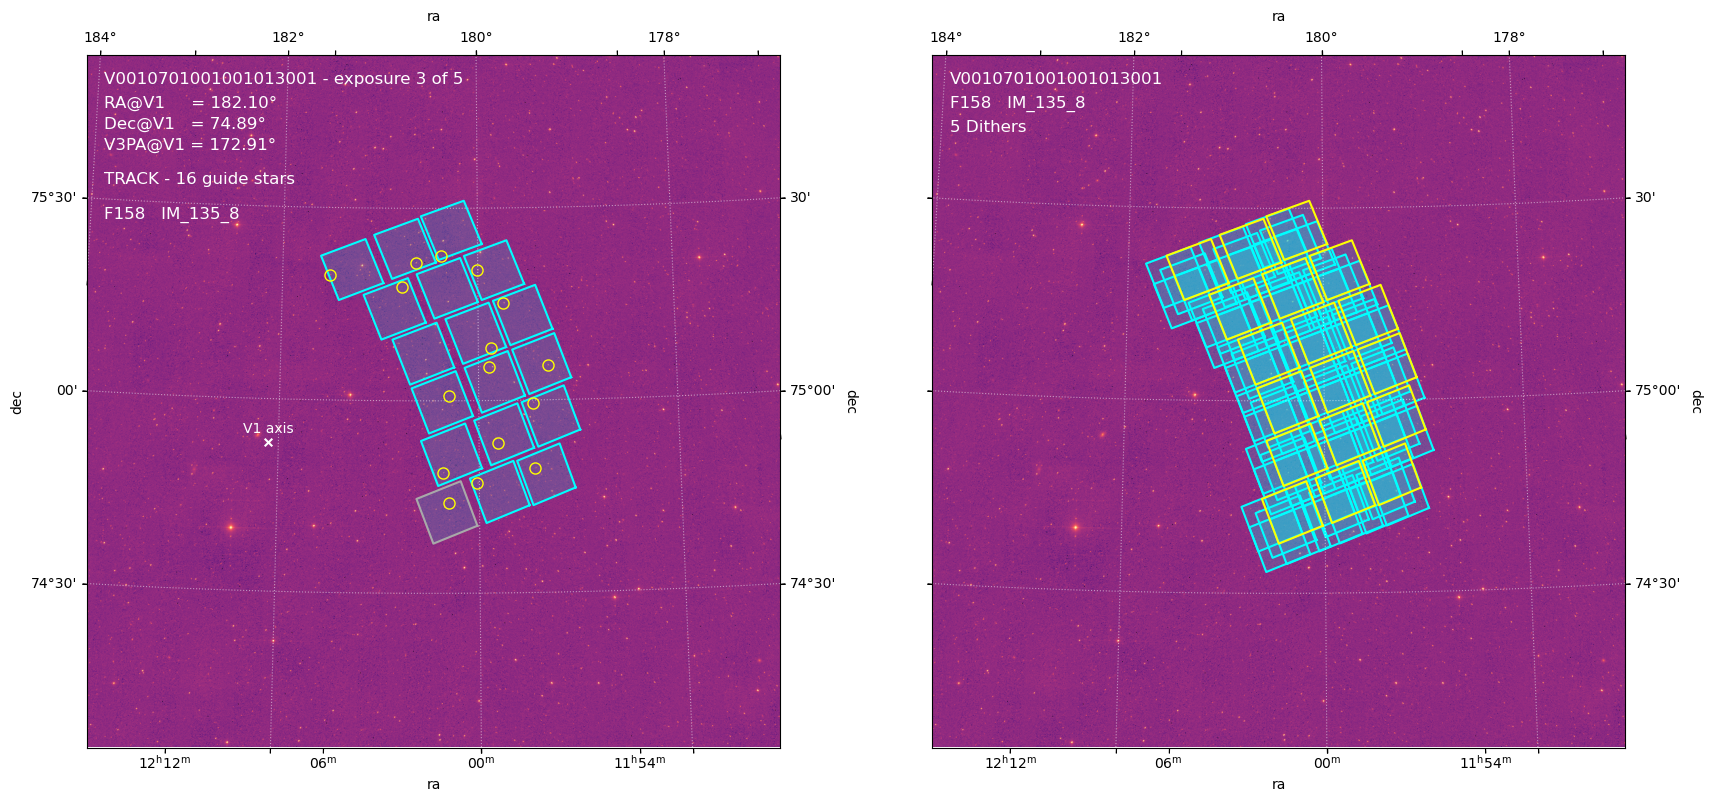

In [35]:
#filename = "/Users/lajoie/Downloads/2026274143037_2026077141053_opup/SCF_2026274143037_29564050/V0010601001001001001.vst"
filename = "/Users/lajoie/Downloads/2026274142359_2026078154610_opup/SCF_2026274142359_29565586/V0010701001001013001.vst"
#filename = "/Users/lajoie/Downloads/2026274143039_2026076194959_opup/SCF_2026274143039_29562949/V0010401002001005002.vst"
#filename = "V1010101001001001002.vst"

visit_parser = VisitFileParser(filename)


plot_all = False

if plot_all:
    for block in visit_parser:
        #print(block.fwa, block.matab, block.guide_mode, block.radec)
        block.plot(savefig=True)
else:
    plot_manager( visit_parser, exp_num = 3, savefig=True )
